# Lorenz63/Lorenz96 Metric vs dt (N=10)

This notebook combines the Lorenz63 and Lorenz96 dt sweeps. The first row plots Lorenz63 PF-SED State vs `dt`; the second row plots Lorenz96 ES vs `dt`. Each row has three observation functions: identity, square, and arctan.


In [11]:
import os
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.lines import Line2D

# torch is required to read output_records_*.pt
import torch


In [12]:
# Ensure cwd is project root (where ./save, ./config, and evaluate.py exist)
def find_project_root(start: Path):
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'save').exists() and (candidate / 'config').is_dir() and (candidate / 'evaluate.py').exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
SAVE_DIR = PROJECT_ROOT / 'save'
print('PROJECT_ROOT =', PROJECT_ROOT)
print('SAVE_DIR exists =', SAVE_DIR.exists())


PROJECT_ROOT = /home/bhchen/LearnKalmanGain
SAVE_DIR exists = True


In [13]:
# =========================
# User config for L63/L96 metric-vs-dt curves
# =========================
N = 10
DT_LABELS = [f'{dt:.2f}' for dt in np.arange(0.15, 0.45 + 1e-9, 0.03)]
DT_VALUES = np.array([float(dt) for dt in DT_LABELS], dtype=float)
DT_TICK_LABELS = DT_LABELS[::3]  # 0.09 spacing: 0.15, 0.24, 0.33, 0.42
DT_TICK_VALUES = np.array([float(dt) for dt in DT_TICK_LABELS], dtype=float)

DATASET_ORDER = ['lorenz63', 'lorenz96']
# Hide L63 until the dt sweep is complete. Switch back to DATASET_ORDER for the full 2x3 plot.
PLOT_DATASET_ORDER = ['lorenz96']
OBS_FNS = ['identity', 'square', 'arctan']
OBS_FN_TITLES = {
    'identity': 'Partial + Identity',
    'square': 'Partial + Square',
    'arctan': 'Partial + Arctan',
}
DATASET_ROW_TITLES = {
    'lorenz63': 'L63 SED',
    'lorenz96': 'L96 ES',
}

OBS_FN_SIGMA_Y = {
    'lorenz63': {
        'identity': 2.0,
        'square': 16.97,
        'arctan': 0.32,
    },
    'lorenz96': {
        'identity': 1.0,
        'square': 6.69,
        'arctan': 0.27,
    },
}

METRIC_KEYS = {
    'lorenz63': ['mean_pf_sed', 'mean_pf_crps'],
    'lorenz96': ['mean_es1'],
}
METRIC_NAMES = {
    'lorenz63': 'SED',
    'lorenz96': 'ES',
}

ML_METHOD_LABELS = ['EtE + ES', 'CorrTerms+ES', 'EtE + NL2', 'CorrTerms+NL2']
CLASSIC_METHOD_LABELS = ['EnKF', 'ESRF', 'IEnKF', 'LETKF']
METHOD_LABELS = ML_METHOD_LABELS + CLASSIC_METHOD_LABELS

RESULTS_ROOTS = {
    dataset: SAVE_DIR / f'{dataset}_results'
    for dataset in DATASET_ORDER
}
BENCHMARK_ROOTS = {}
for dataset in DATASET_ORDER:
    candidates = [PROJECT_ROOT / f'benchmark_{dataset}', SAVE_DIR / f'benchmark_{dataset}']
    BENCHMARK_ROOTS[dataset] = next((p for p in candidates if p.exists()), candidates[-1])

FIG_SAVE_DIR = SAVE_DIR / 'figures' / 'lorenz63_lorenz96_metric_vs_dt_notebook'
FIG_SAVE_DIR.mkdir(parents=True, exist_ok=True)

AXIS_LABEL_FONTSIZE = 22
TICK_FONTSIZE = 18
LEGEND_FONTSIZE = 16
PANEL_WIDTH = 3.9
PANEL_HEIGHT = 4.5
LINEWIDTH = 1.8
MARKERSIZE = 5.2

L96_ES_YTICKS = np.array([6, 10, 14, 18], dtype=float)
L96_ES_YLIM = (6, 18)

print('RESULTS_ROOTS =', RESULTS_ROOTS)
print('BENCHMARK_ROOTS =', BENCHMARK_ROOTS)
print('FIG_SAVE_DIR =', FIG_SAVE_DIR)
print('N =', N)
print('DT_LABELS =', DT_LABELS)
print('DT_TICK_LABELS =', DT_TICK_LABELS)


RESULTS_ROOTS = {'lorenz63': PosixPath('/home/bhchen/LearnKalmanGain/save/lorenz63_results'), 'lorenz96': PosixPath('/home/bhchen/LearnKalmanGain/save/lorenz96_results')}
BENCHMARK_ROOTS = {'lorenz63': PosixPath('/home/bhchen/LearnKalmanGain/save/benchmark_lorenz63'), 'lorenz96': PosixPath('/home/bhchen/LearnKalmanGain/save/benchmark_lorenz96')}
FIG_SAVE_DIR = /home/bhchen/LearnKalmanGain/save/figures/lorenz63_lorenz96_metric_vs_dt_notebook
N = 10
DT_LABELS = ['0.15', '0.18', '0.21', '0.24', '0.27', '0.30', '0.33', '0.36', '0.39', '0.42', '0.45']
DT_TICK_LABELS = ['0.15', '0.24', '0.33', '0.42']


In [14]:
def safe_torch_load(path):
    path = str(path)
    try:
        return torch.load(path, map_location='cpu', weights_only=False)
    except TypeError:
        return torch.load(path, map_location='cpu')


def save_figure_png_pdf(fig, png_path, **savefig_kwargs):
    png_path = Path(png_path)
    pdf_path = png_path.with_suffix('.pdf')
    fig.savefig(png_path, **savefig_kwargs)
    fig.savefig(pdf_path, **savefig_kwargs)
    print('Saved:', png_path)
    print('Saved:', pdf_path)
    return png_path, pdf_path


def _record_value(record_dict, key_candidates):
    candidate_bases = [
        record_dict.get('test_results', {}),
        record_dict.get('nn', {}),
        record_dict,
    ]
    for base in candidate_bases:
        if not isinstance(base, dict):
            continue
        for key in key_candidates:
            if key in base and base[key] is not None:
                try:
                    return float(base[key])
                except Exception:
                    continue
    return np.nan


def _record_path_for_dt(method_spec, dt_label, N=N):
    return method_spec['dir'] / f'output_records_{N}_dt{dt_label}.pt'


def _has_any_dt_records(folder, N=N):
    return folder.exists() and any(folder.glob(f'output_records_{N}_dt*.pt'))


def _finite_dt_count(folder, key_candidates, N=N):
    if not folder.exists():
        return 0
    count = 0
    for dt_label in DT_LABELS:
        rec_path = folder / f'output_records_{N}_dt{dt_label}.pt'
        if not rec_path.exists():
            continue
        record = safe_torch_load(rec_path)
        if np.isfinite(_record_value(record, key_candidates)):
            count += 1
    return count


def collect_metric_vs_dt(method_spec, metric_key_candidates, N=N):
    xs, ys, paths = [], [], []
    for dt_label, dt_value in zip(DT_LABELS, DT_VALUES):
        rec_path = _record_path_for_dt(method_spec, dt_label, N=N)
        if rec_path.exists():
            record = safe_torch_load(rec_path)
            val = _record_value(record, metric_key_candidates)
        else:
            val = np.nan
        xs.append(dt_value)
        ys.append(val)
        paths.append(rec_path)
    return np.array(xs, dtype=float), np.array(ys, dtype=float), paths


In [15]:
TRAINING_MODEL_ORDER = {'ES': 0, 'NL2': 1}
TRAINING_LOSS_ORDER = {'EtE-LRes': 0, 'CorrTerms': 1}


def format_training_label(model: str, loss: str) -> str:
    if loss == 'EtE-LRes':
        return f'EtE + {model}'
    return f'{loss}+{model}'


def parse_training_folder(folder_name: str):
    m = re.search(
        r'_(?P<model>es|nl2)_joint_(?P<loss>EtE-LRes|CorrTerms)(?P<tune_part>None|_tuned)?_(?P<obs_fn>.+)$',
        folder_name,
    )
    if not m:
        return None
    tune_part = m.group('tune_part') or ''
    return {
        'model': m.group('model').upper(),
        'loss': m.group('loss'),
        'obs_fn': m.group('obs_fn'),
        'tuned': tune_part == '_tuned',
    }


def _training_tuned_filter(dataset):
    # L63 dt PF eval uses the base cp_1000 folders. L96 dt eval uses fine-tuned folders.
    if dataset == 'lorenz96':
        return True
    if dataset == 'lorenz63':
        return False
    return None


def discover_training_dirs(dataset: str, obs_fn: str):
    root = RESULTS_ROOTS[dataset]
    if (not root.exists()) or (not root.is_dir()):
        return []

    tuned_filter = _training_tuned_filter(dataset)
    metric_keys = METRIC_KEYS[dataset]
    specs = []
    for d in sorted(root.iterdir()):
        if not d.is_dir():
            continue
        meta = parse_training_folder(d.name)
        if meta is None or meta['obs_fn'] != obs_fn:
            continue
        if tuned_filter is not None and meta['tuned'] != tuned_filter:
            continue
        if meta['model'] not in TRAINING_MODEL_ORDER or meta['loss'] not in TRAINING_LOSS_ORDER:
            continue

        label = format_training_label(meta['model'], meta['loss'])
        specs.append({
            'label': label,
            'dir': d,
            'kind': 'train',
            'dataset': dataset,
            'model': meta['model'],
            'loss': meta['loss'],
            'obs_fn': obs_fn,
            'tuned': meta['tuned'],
            'has_dt_outputs': _has_any_dt_records(d),
            'finite_dt_count': _finite_dt_count(d, metric_keys),
        })

    specs.sort(
        key=lambda spec: (
            TRAINING_MODEL_ORDER[spec['model']],
            TRAINING_LOSS_ORDER[spec['loss']],
            -spec['finite_dt_count'],
            spec['dir'].name,
        )
    )
    return specs


def _dedupe_specs_by_label(specs):
    grouped = {}
    for spec in specs:
        grouped.setdefault(spec['label'], []).append(spec)

    out = []
    for label in METHOD_LABELS:
        candidates = grouped.get(label, [])
        if not candidates:
            continue
        # Prefer most valid dt metric points, then the newest folder name.
        best = sorted(candidates, key=lambda s: (s.get('finite_dt_count', 0), s['dir'].name))[-1]
        out.append(best)
    return out


In [16]:
BENCHMARK_METHOD_ORDER = {
    'EnKF': 0,
    'ESRF': 1,
    'iEnKS-PertObs': 2,
    'iEnKS-Sqrt': 2,
    'iEnKS-Order1': 2,
    'LETKF': 3,
}


def _select_ienkf_benchmark_dir(dataset, sigma_y, metric_keys):
    if dataset == 'lorenz63':
        # Match L63_metric_curves.ipynb: the displayed IEnKF curve is iEnKS-PertObs.
        d = BENCHMARK_ROOTS[dataset] / f'benchmark_{dataset}_{sigma_y}_iEnKS-PertObs'
        return (d, 'iEnKS-PertObs') if d.exists() else (None, None)

    methods = ['iEnKS-PertObs', 'iEnKS-Sqrt']
    candidates = [(BENCHMARK_ROOTS[dataset] / f'benchmark_{dataset}_{sigma_y}_{method}', method) for method in methods]
    finite_candidates = [
        (d, method, _finite_dt_count(d, metric_keys))
        for d, method in candidates
        if d.exists()
    ]
    finite_candidates = [item for item in finite_candidates if item[2] > 0]
    if finite_candidates:
        return sorted(finite_candidates, key=lambda item: (item[2], -methods.index(item[1])))[-1][:2]

    for d, method in candidates:
        if d.exists():
            return d, method
    return None, None


def discover_benchmark_dirs(dataset: str, obs_fn: str):
    sigma_y = OBS_FN_SIGMA_Y[dataset][obs_fn]
    metric_keys = METRIC_KEYS[dataset]
    specs = []

    if dataset == 'lorenz63':
        direct_methods = ['EnKF', 'ESRF']
    elif dataset == 'lorenz96':
        direct_methods = ['EnKF', 'LETKF']
    else:
        direct_methods = ['EnKF']

    for method in direct_methods:
        d = BENCHMARK_ROOTS[dataset] / f'benchmark_{dataset}_{sigma_y}_{method}'
        if d.is_dir():
            specs.append({
                'label': method,
                'dir': d,
                'kind': 'classic',
                'dataset': dataset,
                'method': method,
                'obs_fn': obs_fn,
                'finite_dt_count': _finite_dt_count(d, metric_keys),
            })

    ienkf_dir, ienkf_source = _select_ienkf_benchmark_dir(dataset, sigma_y, metric_keys)
    if ienkf_dir is not None:
        specs.append({
            'label': 'IEnKF',
            'dir': ienkf_dir,
            'kind': 'classic',
            'dataset': dataset,
            'method': ienkf_source,
            'obs_fn': obs_fn,
            'finite_dt_count': _finite_dt_count(ienkf_dir, metric_keys),
        })

    specs.sort(key=lambda spec: (BENCHMARK_METHOD_ORDER.get(spec['method'], 999), spec['dir'].name))
    return specs


def build_bundle(dataset: str, obs_fn: str):
    training_specs = _dedupe_specs_by_label(discover_training_dirs(dataset, obs_fn))
    benchmark_specs = _dedupe_specs_by_label(discover_benchmark_dirs(dataset, obs_fn))
    return {
        'dataset': dataset,
        'obs_fn': obs_fn,
        'sigma_y': OBS_FN_SIGMA_Y[dataset][obs_fn],
        'training_specs': training_specs,
        'benchmark_specs': benchmark_specs,
        'method_specs': training_specs + benchmark_specs,
    }


In [17]:
bundles = {
    dataset: {obs_fn: build_bundle(dataset, obs_fn) for obs_fn in OBS_FNS}
    for dataset in DATASET_ORDER
}
method_specs = {
    dataset: {obs_fn: bundles[dataset][obs_fn]['method_specs'] for obs_fn in OBS_FNS}
    for dataset in DATASET_ORDER
}

for dataset in DATASET_ORDER:
    print('##################################################')
    print(dataset)
    for obs_fn in OBS_FNS:
        bundle = bundles[dataset][obs_fn]
        print('==================================================')
        print(f'obs_fn={obs_fn} | sigma_y={bundle["sigma_y"]}')
        print('Training dirs used:', len(bundle['training_specs']))
        for spec in bundle['training_specs']:
            print('  -', spec['label'], '| valid dt:', spec['finite_dt_count'], '|', spec['dir'])
        print('Classic dirs used:', len(bundle['benchmark_specs']))
        for spec in bundle['benchmark_specs']:
            print('  -', spec['label'], f'({spec["method"]})', '| valid dt:', spec['finite_dt_count'], '|', spec['dir'])

        if dataset == 'lorenz63':
            print('Expected ML dt files:')
            for spec in bundle['training_specs']:
                print('    ', spec['dir'] / 'output_records_10_dt{dt}.pt')
            print('Expected benchmark dt files:')
            for spec in bundle['benchmark_specs']:
                print('    ', spec['dir'] / 'output_records_10_dt{dt}.pt')


##################################################
lorenz63
obs_fn=identity | sigma_y=2.0
Training dirs used: 4
  - EtE + ES | valid dt: 0 | /home/bhchen/LearnKalmanGain/save/lorenz63_results/2026-02-28_14-42lorenz63_2.0_10_60_8192_es_joint_EtE-LResNone_identity
  - CorrTerms+ES | valid dt: 0 | /home/bhchen/LearnKalmanGain/save/lorenz63_results/2026-02-28_14-42lorenz63_2.0_10_60_8192_es_joint_CorrTermsNone_identity
  - EtE + NL2 | valid dt: 0 | /home/bhchen/LearnKalmanGain/save/lorenz63_results/2026-02-28_14-42lorenz63_2.0_10_60_8192_nl2_joint_EtE-LResNone_identity
  - CorrTerms+NL2 | valid dt: 0 | /home/bhchen/LearnKalmanGain/save/lorenz63_results/2026-02-28_14-42lorenz63_2.0_10_60_8192_nl2_joint_CorrTermsNone_identity
Classic dirs used: 3
  - EnKF (EnKF) | valid dt: 0 | /home/bhchen/LearnKalmanGain/save/benchmark_lorenz63/benchmark_lorenz63_2.0_EnKF
  - ESRF (ESRF) | valid dt: 0 | /home/bhchen/LearnKalmanGain/save/benchmark_lorenz63/benchmark_lorenz63_2.0_ESRF
  - IEnKF (iEnKS-PertOb

In [18]:
# Match the color assignment used in L96_metric_curves.ipynb.
METHOD_COLOR_ORDER = [
    'ESRF',
    'EnKF',
    'IEnKF',
    'EtE + ES',
    'CorrTerms+ES',
    'EtE + NL2',
    'CorrTerms+NL2',
    'LETKF',
]
COLOR_CYCLE = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
METHOD_COLORS = {
    label: COLOR_CYCLE[idx % len(COLOR_CYCLE)]
    for idx, label in enumerate(METHOD_COLOR_ORDER)
}
METHOD_STYLES = {
    'EtE + ES': '-',
    'CorrTerms+ES': '-',
    'EtE + NL2': '-',
    'CorrTerms+NL2': '-',
    'EnKF': '--',
    'ESRF': '--',
    'IEnKF': '--',
    'LETKF': '--',
}

LEGEND_ROW_1 = ['EtE + ES', 'CorrTerms+ES', 'EtE + NL2', 'CorrTerms+NL2']
LEGEND_ROW_2 = ['EnKF', 'ESRF', 'IEnKF', 'LETKF']


def _legend_labels_two_rows(available_labels):
    row_1 = [label for label in LEGEND_ROW_1 if label in available_labels]
    row_2 = [label for label in LEGEND_ROW_2 if label in available_labels]
    ncol = max(len(row_1), len(row_2), 1)
    labels = []
    for col_idx in range(ncol):
        if col_idx < len(row_1):
            labels.append(row_1[col_idx])
        if col_idx < len(row_2):
            labels.append(row_2[col_idx])
    return labels, ncol


def _format_dt_axis(ax):
    ax.set_xticks(DT_TICK_VALUES)
    ax.set_xticklabels(DT_TICK_LABELS)
    ax.set_xlim(DT_VALUES[0] - 0.015, DT_VALUES[-1] + 0.015)
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
    ax.grid(alpha=0.3)


def _apply_metric_axis(ax, dataset):
    if dataset == 'lorenz96':
        ax.set_ylim(*L96_ES_YLIM)
        ax.set_yticks(L96_ES_YTICKS)
        ax.set_yticklabels([str(int(tick)) for tick in L96_ES_YTICKS])
    elif dataset == 'lorenz63':
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))


def _collect_curves(dataset, obs_fn):
    curves = {}
    for spec in method_specs[dataset][obs_fn]:
        label = spec['label']
        x, y, paths = collect_metric_vs_dt(spec, METRIC_KEYS[dataset], N=N)
        curves[label] = {'x': x, 'y': y, 'paths': paths, 'spec': spec}
    return curves


In [19]:
# Print a compact missing-data summary before plotting.
for dataset in PLOT_DATASET_ORDER:
    print('##################################################')
    print(dataset, '| metric:', METRIC_NAMES[dataset], '| keys:', METRIC_KEYS[dataset])
    for obs_fn in OBS_FNS:
        curves = _collect_curves(dataset, obs_fn)
        print('==================================================')
        print(f'obs_fn={obs_fn}')
        for label in METHOD_LABELS:
            curve = curves.get(label)
            if curve is None:
                print(f'  - {label}: missing method directory')
                continue
            valid_count = int(np.isfinite(curve['y']).sum())
            missing_dts = [dt for dt, val in zip(DT_LABELS, curve['y']) if not np.isfinite(val)]
            if missing_dts:
                print(f'  - {label}: {valid_count}/{len(DT_LABELS)} valid, missing dt={missing_dts}')
            else:
                print(f'  - {label}: {valid_count}/{len(DT_LABELS)} valid')


##################################################
lorenz96 | metric: ES | keys: ['mean_es1']
obs_fn=identity
  - EtE + ES: 11/11 valid
  - CorrTerms+ES: 11/11 valid
  - EtE + NL2: 11/11 valid
  - CorrTerms+NL2: 11/11 valid
  - EnKF: 11/11 valid
  - ESRF: missing method directory
  - IEnKF: 2/11 valid, missing dt=['0.21', '0.24', '0.27', '0.30', '0.33', '0.36', '0.39', '0.42', '0.45']
  - LETKF: 11/11 valid
obs_fn=square
  - EtE + ES: 11/11 valid
  - CorrTerms+ES: 11/11 valid
  - EtE + NL2: 11/11 valid
  - CorrTerms+NL2: 11/11 valid
  - EnKF: 11/11 valid
  - ESRF: missing method directory
  - IEnKF: 2/11 valid, missing dt=['0.21', '0.24', '0.27', '0.30', '0.33', '0.36', '0.39', '0.42', '0.45']
  - LETKF: 11/11 valid
obs_fn=arctan
  - EtE + ES: 11/11 valid
  - CorrTerms+ES: 11/11 valid
  - EtE + NL2: 11/11 valid
  - CorrTerms+NL2: 11/11 valid
  - EnKF: 11/11 valid
  - ESRF: missing method directory
  - IEnKF: 5/11 valid, missing dt=['0.15', '0.27', '0.30', '0.33', '0.36', '0.39']
  - LE

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_lorenz96_metric_vs_dt_notebook/L96_metric_vs_dt_N10_1x3.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_lorenz96_metric_vs_dt_notebook/L96_metric_vs_dt_N10_1x3.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_lorenz96_metric_vs_dt_notebook/L96_metric_vs_dt_N10_1x3_legend.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_lorenz96_metric_vs_dt_notebook/L96_metric_vs_dt_N10_1x3_legend.pdf


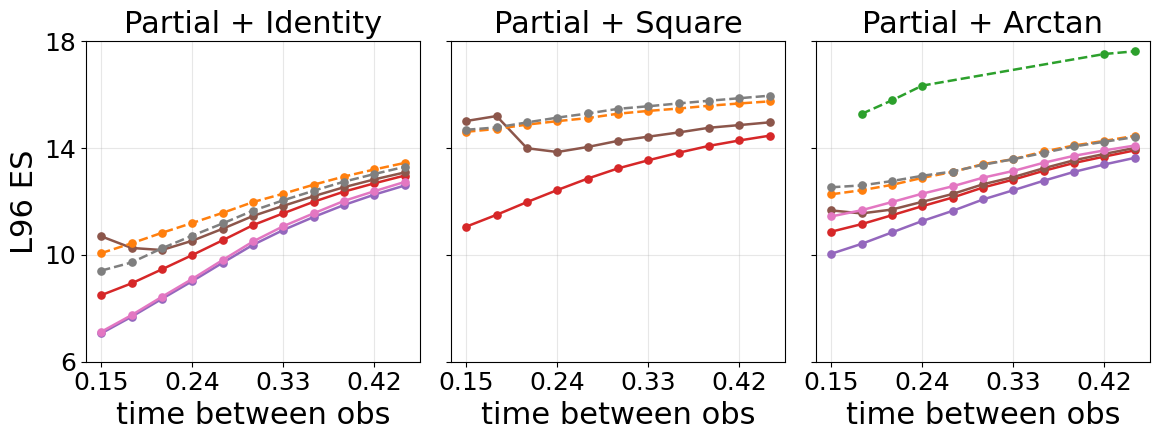

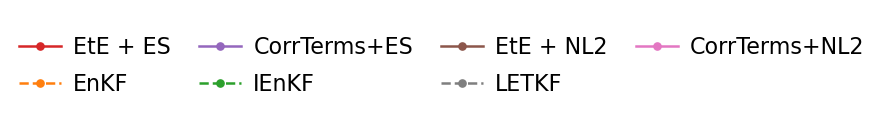

In [ ]:
def plot_l63_l96_metric_vs_dt(out_stem=None, plot_datasets=None):
    plot_datasets = list(plot_datasets or PLOT_DATASET_ORDER)
    if out_stem is None:
        out_stem = 'L63_L96_metric_vs_dt_N10_2x3' if plot_datasets == DATASET_ORDER else 'L96_metric_vs_dt_N10_1x3'
    fig, axes = plt.subplots(
        len(plot_datasets),
        len(OBS_FNS),
        figsize=(PANEL_WIDTH * len(OBS_FNS), PANEL_HEIGHT * len(plot_datasets)),
        sharex=True,
        sharey='row',
    )

    legend_handles = {}
    axes = np.atleast_2d(axes)

    for row, dataset in enumerate(plot_datasets):
        for col, obs_fn in enumerate(OBS_FNS):
            ax = axes[row, col]
            curves = _collect_curves(dataset, obs_fn)
            for label in METHOD_LABELS:
                curve = curves.get(label)
                if curve is None:
                    continue
                y = curve['y']
                valid = np.isfinite(y)
                if not np.any(valid):
                    print(f'[warn] no valid {METRIC_NAMES[dataset]} points for dataset={dataset}, obs_fn={obs_fn}, method={label}')
                    continue

                (line,) = ax.plot(
                    curve['x'][valid],
                    y[valid],
                    marker='o',
                    linewidth=LINEWIDTH,
                    markersize=MARKERSIZE,
                    linestyle=METHOD_STYLES.get(label, '-'),
                    color=METHOD_COLORS[label],
                    label=label,
                )
                legend_handles[label] = line

            if row == 0:
                ax.set_title(OBS_FN_TITLES.get(obs_fn, obs_fn), fontsize=AXIS_LABEL_FONTSIZE)
            if row == len(plot_datasets) - 1:
                ax.set_xlabel('Time Between Obs', fontsize=AXIS_LABEL_FONTSIZE)
            _format_dt_axis(ax)
            _apply_metric_axis(ax, dataset)

        axes[row, 0].set_ylabel(DATASET_ROW_TITLES[dataset], fontsize=AXIS_LABEL_FONTSIZE)

    fig.tight_layout(h_pad=1.0, w_pad=1.1)

    out = FIG_SAVE_DIR / f'{out_stem}.png'
    save_figure_png_pdf(fig, out, dpi=180, bbox_inches='tight')

    legend_fig = save_metric_vs_dt_legend(legend_handles, out_stem=f'{out_stem}_legend')
    plt.show()
    plt.close(legend_fig)
    return fig


def save_metric_vs_dt_legend(legend_handles, out_stem='metric_vs_dt_legend'):
    legend_labels, legend_ncol = _legend_labels_two_rows(legend_handles.keys())
    legend_handles_ordered = [legend_handles[label] for label in legend_labels]

    legend_fig, legend_ax = plt.subplots(figsize=(max(7.4, 1.65 * legend_ncol), 1.15))
    legend_ax.axis('off')
    legend_ax.legend(
        legend_handles_ordered,
        legend_labels,
        loc='center',
        ncol=legend_ncol,
        frameon=False,
        fontsize=LEGEND_FONTSIZE,
        handlelength=1.9,
        handletextpad=0.55,
        columnspacing=1.25,
        labelspacing=0.65,
    )
    legend_fig.tight_layout(pad=0.1)
    out = FIG_SAVE_DIR / f'{out_stem}.png'
    save_figure_png_pdf(legend_fig, out, dpi=180, bbox_inches='tight', pad_inches=0.02)
    return legend_fig


fig = plot_l63_l96_metric_vs_dt()
plt.close(fig)
